# Demonstration of `distance_model`
Bayesian kinematic distance calculator.

Trey Wenger, 2025

In [1]:
import pickle
import numpy as np
from scipy.stats import multivariate_normal
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from physiokinematic.distance_model import distance_model

In [2]:
# Load Reid et al. (2019) rotation curve parameters
with open("../../../data/reid19_params.pkl", "rb") as f:
    reid19_params = pickle.load(f)
print(reid19_params.keys())

samples = reid19_params['full'].resample(1_000)

# R0, Usun, Vsun, Wsun, a2, a3
samples = samples[np.array([0,1,2,3,6,7]), :]

reid19_fit = multivariate_normal.fit(samples.T)

dict_keys(['R0', 'Usun', 'Vsun', 'Wsun', 'Upec', 'Vpec', 'a2', 'a3', 'full'])


/tmp/ipykernel_331187/3720529096.py:3: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  reid19_params = pickle.load(f)


In [3]:
model = distance_model(
    32.5, # Galactic longitude (degrees)
    1.25, # Galactic latitude (degrees)
    42.0, # LSR velocity (km/s)
    0.5, # LSR velocity uncertainty (km/s)
    reid19_fit[0], # Prior mean on rotation curve parameters
    reid19_fit[1], # Prior covariance on rotation curve parameters
    prior_Rgal = 5.0, # Prior width on Galactocentric radius (kpc)
    prior_kdar = [0.5, 0.5], # Prior shape for kinematic distance ambiguity resolution
    vlsr_sigma = 10.0, # Assumed LSR velocity systematic uncertainty (km/s)
)

In [4]:
model

 rotcurve ~ MultivariateNormal(f(), <constant>)
Rgal_norm ~ Gamma(0.5, f())
   kdar_w ~ Categorical(<constant>)
     Rgal ~ Deterministic(f(Rgal_norm, rotcurve))
 distance ~ Deterministic(f(rotcurve, Rgal_norm))
 vlsr_obs ~ Normal(f(rotcurve, Rgal_norm), f())

In [5]:
# sample prior predictive
with model:
    prior = pm.sample_prior_predictive(1_000)

Sampling: [Rgal_norm, kdar_w, rotcurve, vlsr_obs]


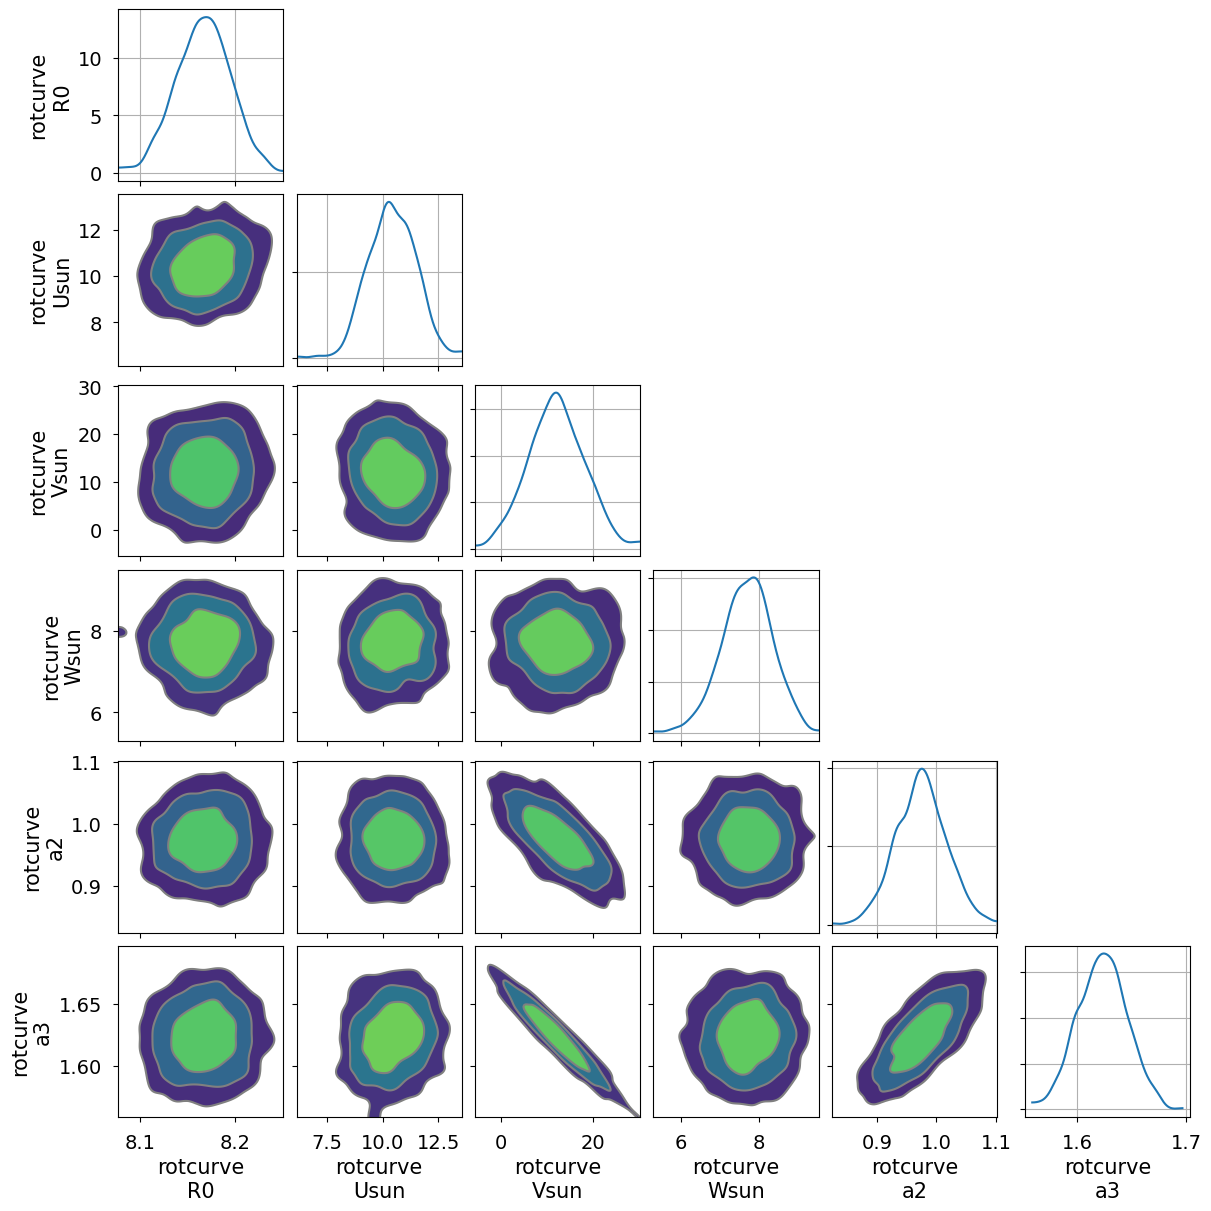

In [6]:
# plot prior samples
_ = pm.plot_pair(prior.prior["rotcurve"], marginals=True, figsize=(12, 12), kind='kde', backend_kwargs={"layout": "constrained"})

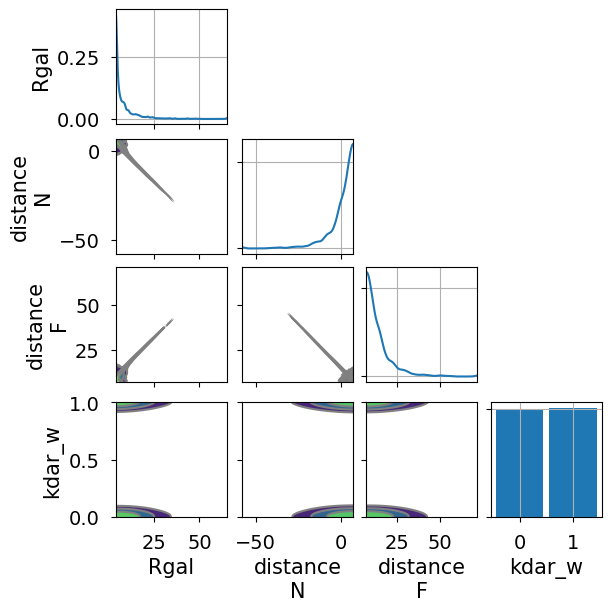

In [7]:
# plot prior samples
_ = pm.plot_pair(prior.prior, marginals=True, figsize=(6, 6), kind='kde', backend_kwargs={"layout": "constrained"}, var_names=["Rgal", "distance", "kdar_w"])

In [8]:
with model:
    trace = pm.sample()

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [rotcurve, Rgal_norm]
>BinaryGibbsMetropolis: [kdar_w]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


In [9]:
az.summary(trace, hdi_prob=0.68, var_names=["rotcurve", "Rgal", "distance", "kdar_w"])

,mean,sd,hdi_16%,hdi_84%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rotcurve[R0],8.166,0.027,8.138,8.192,0.000,0.000,4150.0,2853.0,1.0
rotcurve[Usun],10.484,1.039,9.465,11.480,0.016,0.017,4151.0,2842.0,1.0
rotcurve[Vsun],12.269,6.245,5.464,17.982,0.130,0.096,2297.0,2485.0,1.0
rotcurve[Wsun],7.700,0.627,7.076,8.315,0.010,0.011,3740.0,2217.0,1.0
rotcurve[a2],0.975,0.043,0.929,1.015,0.001,0.001,2724.0,2816.0,1.0
rotcurve[a3],1.622,0.023,1.600,1.647,0.000,0.000,2243.0,2403.0,1.0
Rgal,6.203,0.438,5.750,6.606,0.008,0.007,3046.0,2192.0,1.0
distance[N],2.526,0.627,1.947,3.167,0.011,0.012,3050.0,2173.0,1.0
distance[F],11.252,0.626,10.606,11.829,0.011,0.012,3047.0,2192.0,1.0
kdar_w,0.502,0.500,0.000,1.000,0.004,0.000,14408.0,4000.0,1.0


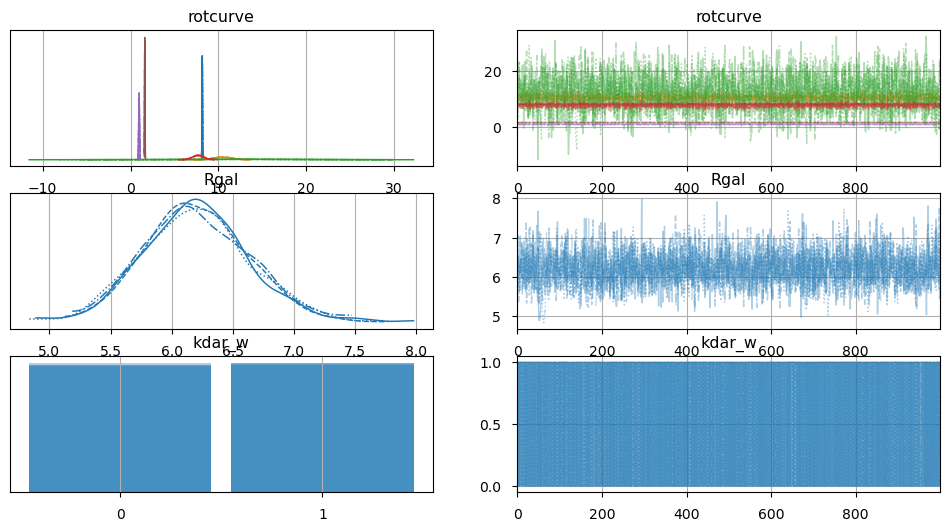

In [10]:
_ = pm.plot_trace(trace.posterior, var_names=["rotcurve", "Rgal", "kdar_w"])

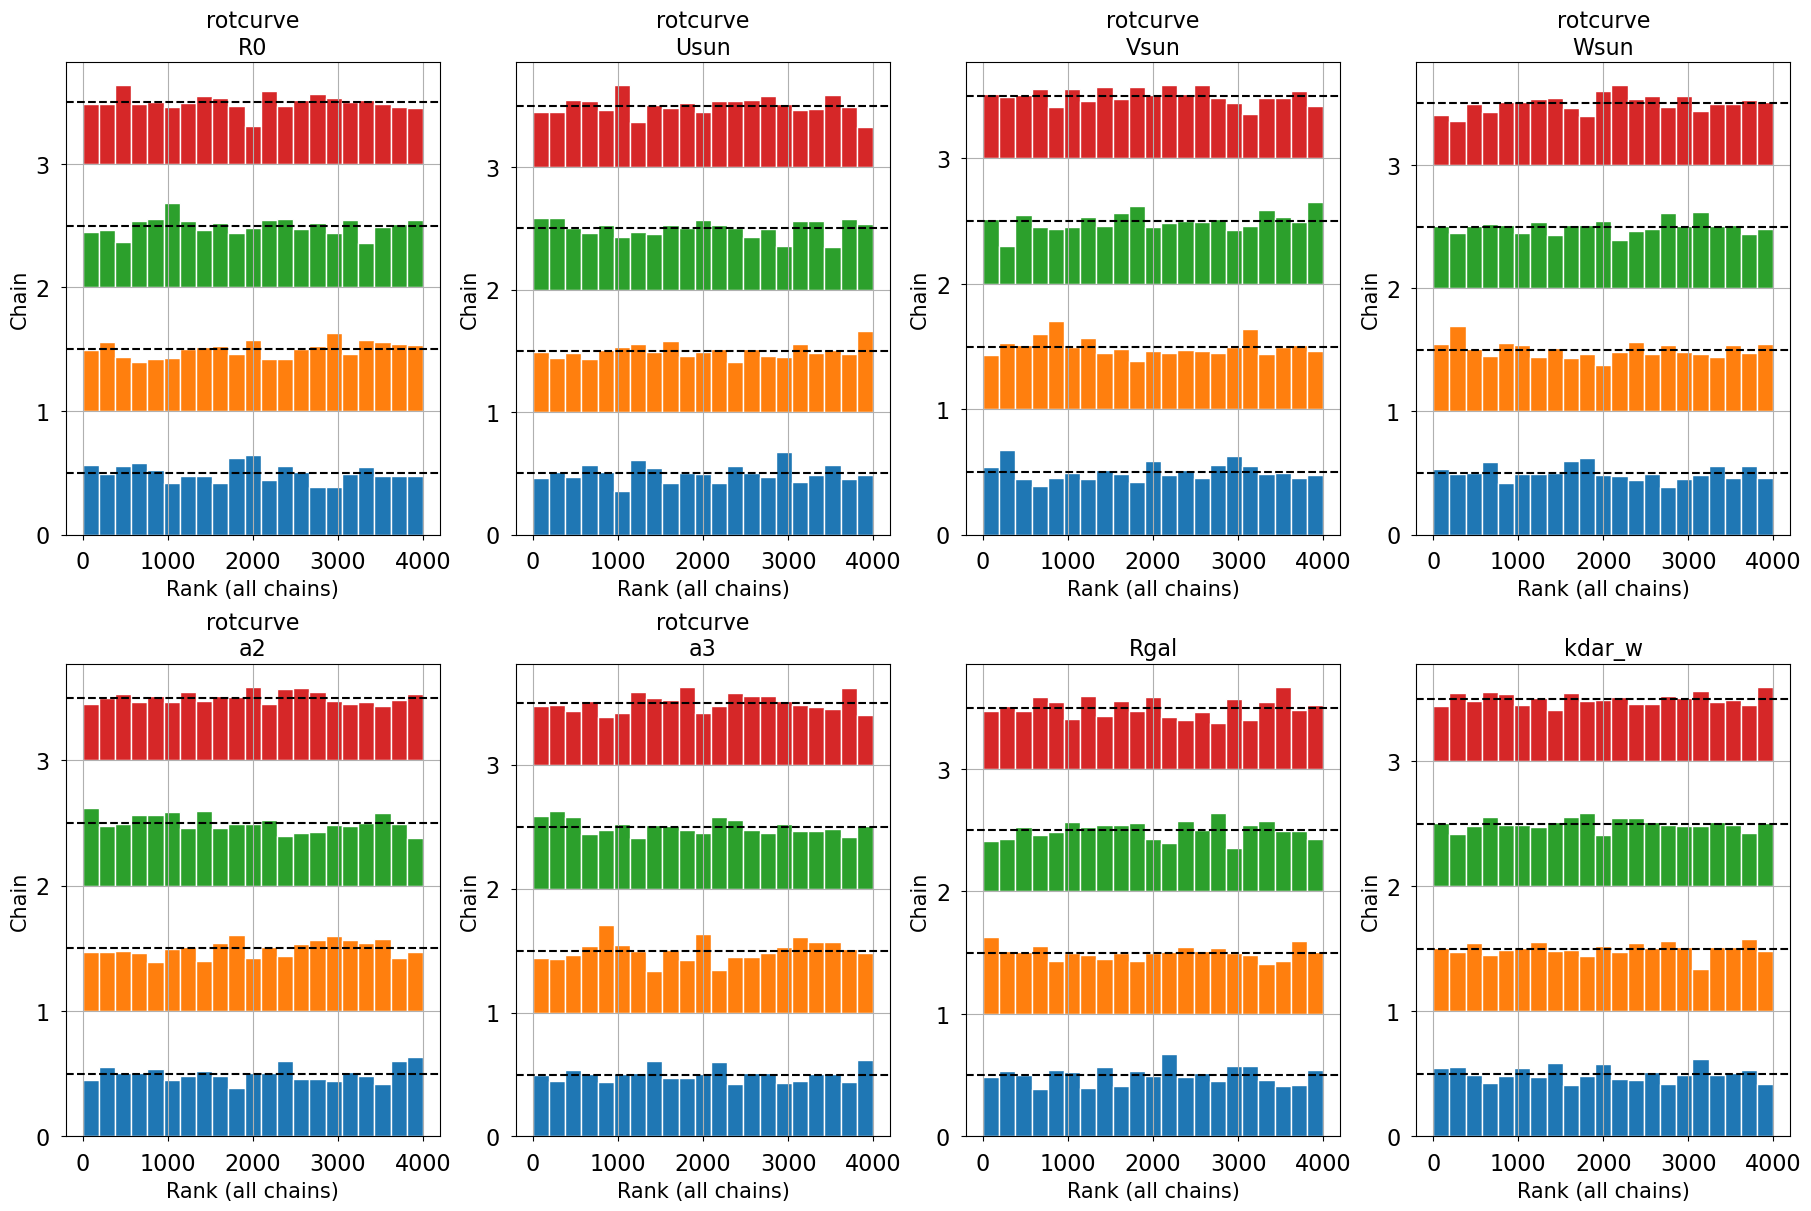

In [11]:
_ = pm.plot_rank(trace.posterior, var_names=["rotcurve", "Rgal", "kdar_w"], figsize=(18, 12), backend_kwargs={"layout": "constrained"})

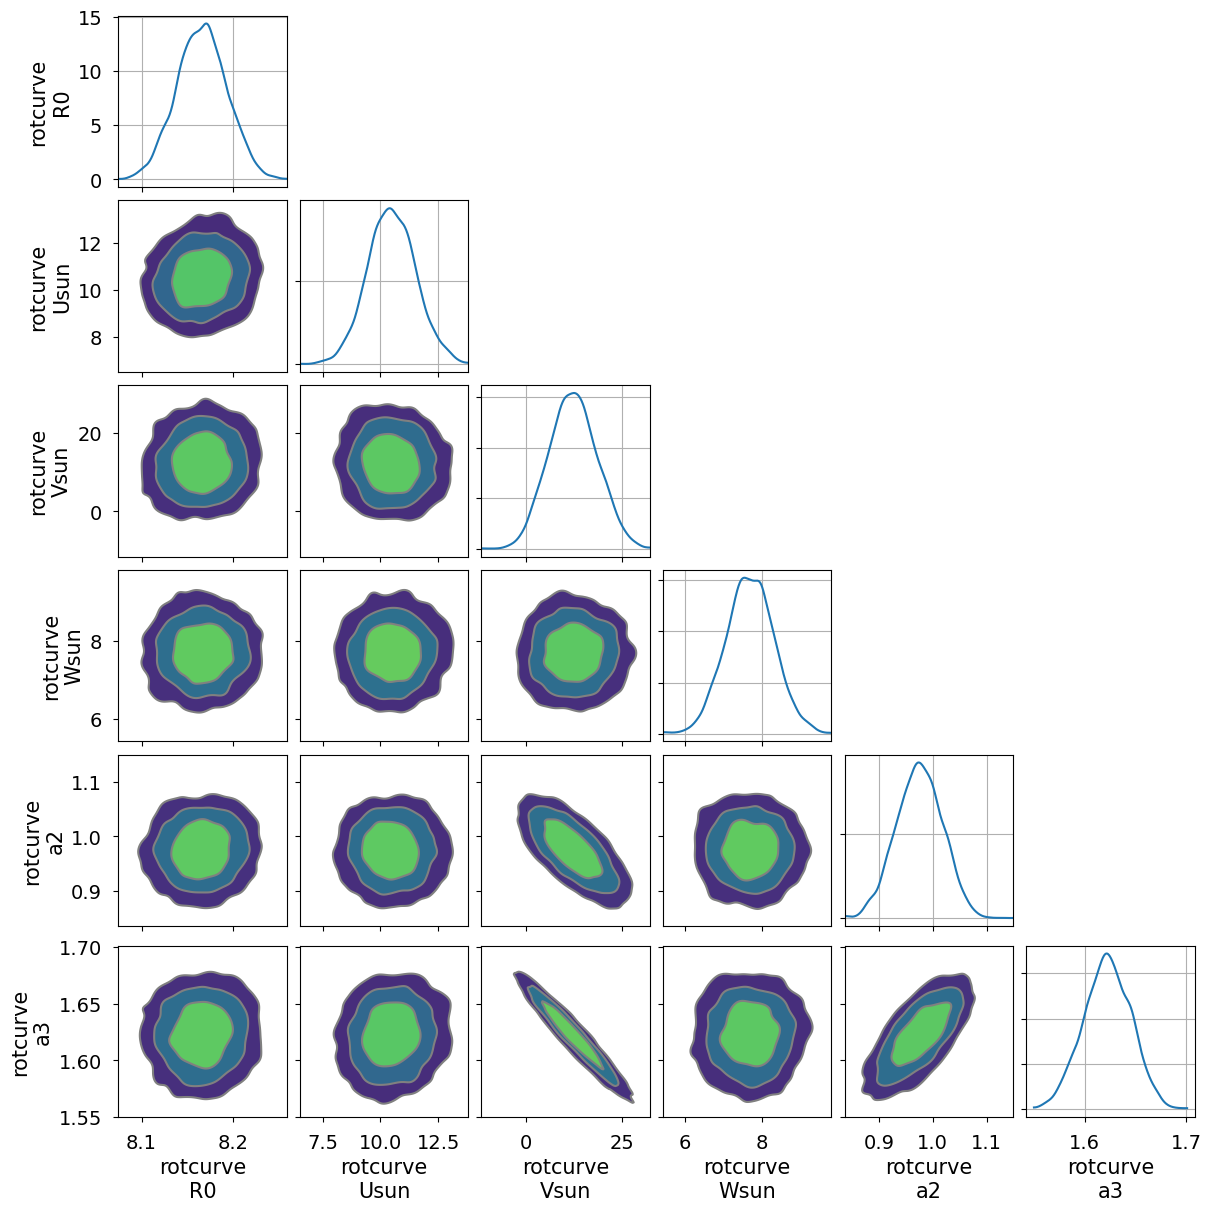

In [12]:
# plot posterior samples
_ = pm.plot_pair(trace.posterior["rotcurve"], marginals=True, figsize=(12, 12), kind='kde', backend_kwargs={"layout": "constrained"})

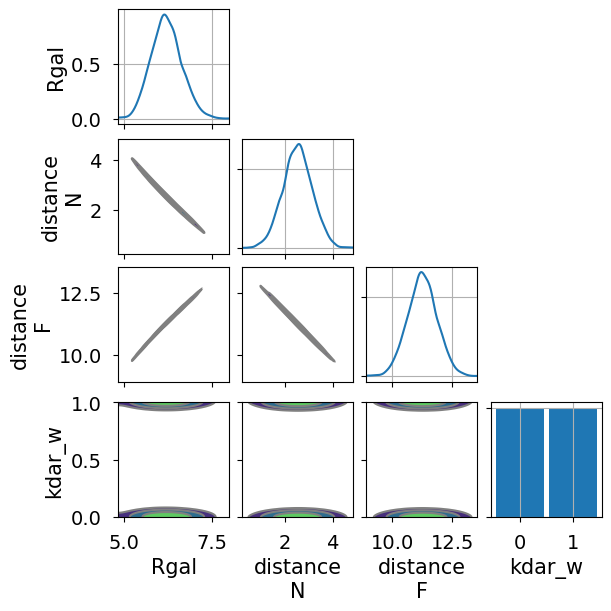

In [13]:
# plot posterior samples
_ = pm.plot_pair(trace.posterior, marginals=True, figsize=(6, 6), kind='kde', backend_kwargs={"layout": "constrained"}, var_names=["Rgal", "distance", "kdar_w"])

In [14]:
# sample posterior predictive
with model:
    posterior = pm.sample_posterior_predictive(trace.sel(draw=slice(None, None, 1)))

Sampling: [vlsr_obs]


In [15]:
# drop samples with distance <= 0.0
bad_distance = trace.posterior["distance"] <= 0.0

result = {}

# Hyperparameters & distance-independent parameters
params = ["Rgal"]
for param in params:
    if param not in trace.posterior:
        continue
    post = trace.posterior[param].data.flatten()
    result[f"{param}_mean"] = np.mean(post)
    result[f"{param}_std"] = np.std(post)
    result[f"{param}_median"] = np.median(post)
    hdi = az.hdi(post, hdi_prob=0.90)
    result[f"{param}_hdi5"] = hdi[0]
    result[f"{param}_hdi95"] = hdi[1]

# Distance-dependent parameters
params = [
    "distance",
]
for param in params:
    posterior_N = trace.posterior[param].sel(kdar="N").data[
        (trace.posterior["kdar_w"] == 0) * (~bad_distance.sel(kdar="N"))
    ]
    posterior_F = trace.posterior[param].sel(kdar="F").data[
        (trace.posterior["kdar_w"] == 1) * (~bad_distance.sel(kdar="F"))
    ]
    posterior_T = np.concatenate([posterior_N, posterior_F])
    for kdar, post in zip(["N", "F", "T"], [posterior_N, posterior_F, posterior_T]):
        if len(post) < 5:
            continue
        result[f"{param}_{kdar}_mean"] = np.mean(post)
        result[f"{param}_{kdar}_std"] = np.std(post)
        result[f"{param}_{kdar}_median"] = np.median(post)
        hdi = az.hdi(post, hdi_prob=0.90)
        result[f"{param}_{kdar}_hdi5"] = hdi[0]
        result[f"{param}_{kdar}_hdi95"] = hdi[1]

    result[f"{param}_samples"] = posterior_T

# KDAR weight
result["kdar_w"] = len(posterior_F)/len(posterior_T)

# Observed parameters
params = [
    "vlsr_obs",
]
for param in params:
    post = posterior.posterior_predictive[param].data.flatten()
    result[f"{param}_mean"] = np.mean(post)
    result[f"{param}_std"] = np.std(post)
    result[f"{param}_median"] = np.median(post)
    hdi = az.hdi(post, hdi_prob=0.90)
    result[f"{param}_hdi5"] = hdi[0]
    result[f"{param}_hdi95"] = hdi[1]
    result[f"{param}_samples"] = post

Text(0.5, 0, '$R$ (kpc)')

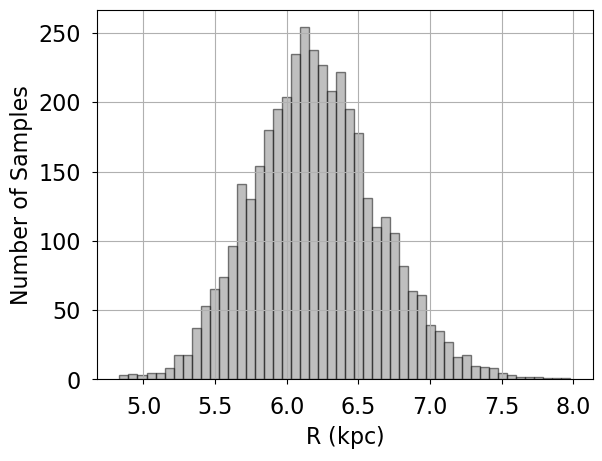

In [16]:
fig, ax = plt.subplots()
ax.hist(trace.posterior["Rgal"].data.flatten(), bins=50, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel("$R$ (kpc)")

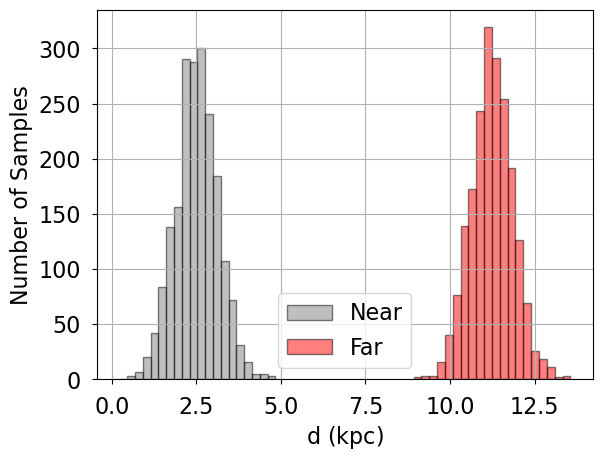

In [17]:
fig, ax = plt.subplots()
bins=20
ax.hist(trace.posterior["distance"].sel(kdar='N').data.flatten(), weights=(1-trace.posterior["kdar_w"].data.flatten()), bins=bins, color="gray", edgecolor="k", alpha=0.5, label="Near")
ax.hist(trace.posterior["distance"].sel(kdar='F').data.flatten(), weights=trace.posterior["kdar_w"].data.flatten(), bins=bins, color="red", edgecolor="k", alpha=0.5, label="Far")
ax.set_ylabel("Number of Samples")
ax.set_xlabel("$d$ (kpc)")
ax.legend(loc="best")

Text(0.5, 0, '$d$ (kpc)')

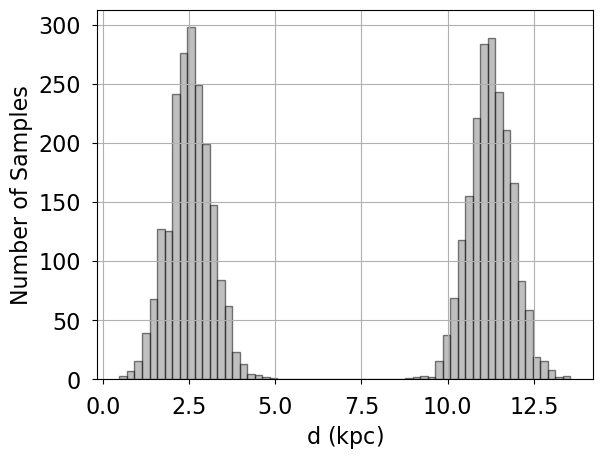

In [18]:
fig, ax = plt.subplots()
bins=60
ax.hist(result["distance_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel("$d$ (kpc)")

In [19]:
print(result["kdar_w"])

0.502


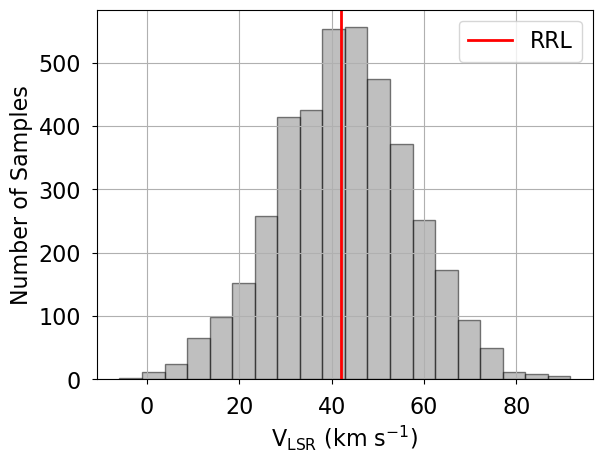

In [20]:
# plot posterior predictive samples
fig, ax = plt.subplots()
bins=20
ax.hist(result["vlsr_obs_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.axvline(42.0, color="r", lw=2, label="RRL")
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$V_{\rm LSR}$ (km s$^{-1}$)")
ax.legend(loc="best")